<a href="https://colab.research.google.com/github/NurRahmi98/Caikit-and-Hugging-Face/blob/master/ElbowMethod_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving DATA RESPONDEN.xlsx to DATA RESPONDEN (1).xlsx


In [ ]:
!pip install openpyxl  # agar bisa membaca file .xlsx

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
# Ambil nama file hasil upload
file_name = list(uploaded.keys())[0]

# Tampilkan nama-nama sheet di dalam file
xls = pd.ExcelFile(file_name)
print("Sheet yang tersedia:", xls.sheet_names)

Sheet yang tersedia: ['Form Responses 1']


In [ ]:
# Ambil nama file hasil upload
file_name = list(uploaded.keys())[0]

# Tampilkan nama sheet yang ada di file
xls = pd.ExcelFile(file_name)
print("Sheet yang tersedia:", xls.sheet_names)

# Baca data dari sheet yang sesuai
df = pd.read_excel(file_name, sheet_name='Form Responses 1')

# Tampilkan seluruh data (ingat, ini bisa sangat besar jika data banyak)
df

Sheet yang tersedia: ['Form Responses 1']


,Timestamp,Nama,Jenis Kelamin,Asal Sekolah,1. Saya tahu bahwa di sekolah ada program makanan gratis.,2. Saya memahami syarat untuk menerima makanan gratis.,3. Informasi tentang jadwal dan lokasi pembagian mudah diperoleh.,4. Sosialisasi program dilakukan dengan jelas oleh pemerintah/instansi terkait.,5. Lokasi pembagian makanan mudah dijangkau.,6. Proses mendapatkan makanan gratis tidak berbelit.,...,14. Program ini tersedia secara rutin sesuai jadwal.,15. Tidak ada kesulitan dalam mengakses program ini.,16. Saya percaya program ini dikelola dengan transparan.,17. Tidak ada pihak yang diistimewakan dalam pembagian makanan.,18. Pemerintah atau lembaga pelaksana dapat dipercaya menjaga keadilan program.,19. Saya puas dengan pelaksanaan program makanan gratis ini.,20. Program ini membantu meringankan beban ekonomi keluarga saya.,21. Saya akan mendukung jika program ini dilanjutkan di masa depan.,22. Saya akan merekomendasikan program ini kepada warga lain.,23. Program ini sesuai dengan tujuan untuk meningkatkan kesejahteraan masyarakat.
0,2025-11-03 15:41:06.746,Annisa,Perempuan,SMK Negeri 1 Manokwari,5,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
1,2025-11-03 15:50:25.091,Abigail,Perempuan,SMAN 1 Manokwari,5,4,4,3,3,4,...,4,4,3,5,3,4,5,5,4,5
2,2025-11-03 15:50:41.179,awa,Perempuan,smansa,5,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
3,2025-11-03 15:51:35.553,Annisa Salsabila,Perempuan,SMAN 1 Manokwari,5,5,3,4,5,5,...,5,5,5,5,5,5,5,5,5,5
4,2025-11-03 15:52:50.739,Gita,Perempuan,sma Negeri 1 Manokwari,5,5,5,5,5,5,...,3,5,5,5,5,5,5,5,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,2026-01-23 20:14:09.353,Marvel Imbiri,Laki-laki,SMA NEGERI 2 MANOKWARI,4,4,5,5,5,4,...,5,5,4,5,5,5,5,5,4,5
497,2026-01-23 20:14:20.421,Michele Athalya Simanjutak,Perempuan,SMP Negeri 2 Manokwari,3,4,4,3,4,4,...,3,3,3,4,4,4,4,3,4,3
498,2026-01-23 20:16:01.679,Alidya Nur Rachmani,Perempuan,SMA NEGERI 2 MANOKWARI,5,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
499,2026-01-23 20:20:27.521,AYU WIDYA SARI,Perempuan,SMA N 2 MANOKWARI,5,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5


In [ ]:
# Ambil hanya kolom numerik
X = df.select_dtypes(include=['int64', 'float64'])

# Normalisasi data (standarisasi)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


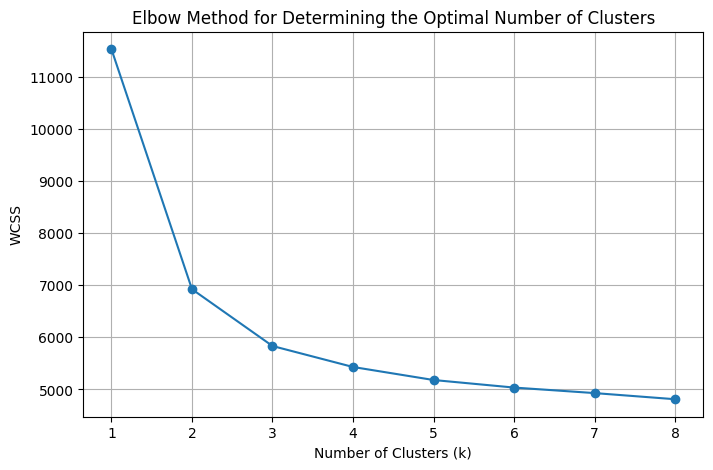

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []  # Within-Cluster Sum of Squares
k_range = range(1, 9)  # Number of clusters from 1 to 8

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow graph
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Determining the Optimal Number of Clusters')
plt.grid(True)
plt.show()


In [ ]:
# 3. Pilih fitur numerik untuk clustering
features = df.select_dtypes(include=['int64', 'float64'])

# 4. Standarisasi fitur agar skala data seimbang
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 5. Hitung SSE untuk k = 1 sampai 14
sse = []
for k in range(1, 13):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    sse.append(kmeans.inertia_)  # inertia = SSE

# 6. Tampilkan nilai SSE per jumlah cluster
print("Nilai SSE untuk setiap jumlah cluster:")
for i, val in enumerate(sse, start=1):
    print(f"Cluster = {i}, SSE = {val:.2f}")

Nilai SSE untuk setiap jumlah cluster:
Cluster = 1, SSE = 11523.00
Cluster = 2, SSE = 6922.76
Cluster = 3, SSE = 5833.43
Cluster = 4, SSE = 5446.03
Cluster = 5, SSE = 5183.57
Cluster = 6, SSE = 5104.49
Cluster = 7, SSE = 4983.35
Cluster = 8, SSE = 4812.94
Cluster = 9, SSE = 4734.05
Cluster = 10, SSE = 4657.39
Cluster = 11, SSE = 4575.76
Cluster = 12, SSE = 4538.75
